In [1]:
import numpy as np
import pandas as pd
# import pulp
import requests
import io
from funcs import get_spot_prices

In [2]:
PV_RATED_MW  = 1.83 #MW
BESS_POW_MW  = 5.0 #MW
BESS_CAP_MWH = 9.0 #MWh
SOC_MIN      = 0.9 #MWh
SOC_MAX      = 8.1 #MWh
LOAD_MW      = 4 #MW -- DC Load
GRID_CAP_MW  = 10.0 #MW
DT           = 0.25 # hours
N_T          = 96 # time steps

In [3]:
pv_inv_loading = np.array([0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00])
pv_inv_eta     = np.array([0.890, 0.932, 0.962, 0.972, 0.978, 0.977, 0.974])

bess_inv_loading = np.array([0.10, 0.20, 0.30, 0.50, 0.75, 1.00])
bess_inv_eta     = np.array([0.905, 0.928, 0.953, 0.974, 0.973, 0.970])

trafo_loading = np.array([0.10, 0.20, 0.30, 0.50, 0.75, 1.00])
trafo_eta     = np.array([0.950, 0.967, 0.978, 0.988, 0.988, 0.986])

boost_loading = np.array([0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00])
boost_eta     = np.array([0.905, 0.938, 0.963, 0.973, 0.979, 0.978, 0.976])

load_dcdc_loading = np.array([0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00])
load_dcdc_eta     = np.array([0.895, 0.922, 0.951, 0.964, 0.974, 0.973, 0.970])

load_rect_loading = np.array([0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00])
load_rect_eta     = np.array([0.870, 0.900, 0.930, 0.948, 0.961, 0.960, 0.957])

def interpolated_eta(P, P_rated, loading_arr, eta_arr):
    loading = np.clip(P / P_rated, loading_arr[0], loading_arr[-1])
    return np.interp(loading, loading_arr, eta_arr)

In [4]:
fetch = False

if fetch:
    spot_df = get_spot_prices('2025-01-01', '2026-01-01', 'DK2')
    spot_df['HourUTC'] = pd.to_datetime(spot_df['HourUTC'])
    spot_df = spot_df.sort_values('HourUTC').reset_index(drop=True)
    spot_df.to_csv('../data/spot_df.csv', index = False)
else:
    spot_df = pd.read_csv('../data/spot_df.csv', parse_dates = ['HourUTC'])

price_hourly = spot_df.set_index('HourUTC')['SpotPriceEUR']
price_15min  = price_hourly.resample('15min').ffill()

Parameter	Value	Meaning
raddatabase	PVGIS-ERA5	ERA5 reanalysis, covers 2005–2023
pvcalculation=1	—	Returns AC power output in W (column P)
peakpower	1830	System size in kWp
pvtechchoice	crystSi	Crystalline silicon panels
angle	30	Tilt from horizontal in degrees
aspect	0	Azimuth: 0 = south, −90 = east, 90 = west
loss	14	Total system losses in % (wiring, soiling, mismatch)
mountingplace	free	Free-standing, not building-integrated

In [5]:
fetch = False

if fetch:
    pvgis_url = (
        "https://re.jrc.ec.europa.eu/api/v5_2/seriescalc"
        "?lat=55.7838&lon=12.5172"
        "&raddatabase=PVGIS-ERA5&startyear=2020&endyear=2020"
        f"&pvcalculation=1&peakpower={PV_RATED_MW*1000}&pvtechchoice=crystSi"
        "&mountingplace=free&angle=30&aspect=0&loss=14&outputformat=csv"
    )

    resp = requests.get(pvgis_url)
    resp.raise_for_status()

    lines = resp.text.splitlines()
    start = next(i for i, l in enumerate(lines) if l.startswith('time'))
    stop  = next((start + 1 + i for i, l in enumerate(lines[start + 1:]) if not l or not l[0].isdigit()), len(lines))

    pv_raw = pd.read_csv(io.StringIO(''.join(lines[start:stop])), index_col='time')
    pv_raw.index = pd.to_datetime(pv_raw.index, format='%Y%m%d:%H%M')


    # Adjust timestamps: replace year 2020 with 2025 (handle Feb 29)
    def _replace_year(ts, year=2025):
        try:
            return ts.replace(year=year)
        except ValueError:
            if ts.month == 2 and ts.day == 29:
                return ts - pd.Timedelta(days=1)
            raise

    pv_raw.index = pv_raw.index.map(lambda t: _replace_year(t, 2025))
    pv_raw.to_csv('../data/pv_raw.csv')
else:
    pv_raw = pd.read_csv('../data/pv_raw.csv', index_col = 'time', parse_dates = ['time'])

pv_hourly = pv_raw['P'] / 1e6
pv_15min  = pv_hourly.resample('15min').interpolate('linear')

In [6]:
from deterministic_MG_scheduler import build_model, solve_model

date = '2025-06-01'

price_day = price_15min[date].values
pv_day    = pv_15min[date].values

model   = build_model(price_day, pv_day, arch='DC', soc_init=4.5)
results = solve_model(model, solver='gurobi')
results['SOC'] = results['SOC'][:-1]
idx        = price_15min[date].index
results_df = pd.DataFrame({k: v for k, v in results.items() if isinstance(v, np.ndarray) and len(v) == N_T }, index=idx)
            
print(results['status'], f"  cost: {results['cost_eur']:.2f} EUR")

optimal   cost: 2167.75 EUR


In [7]:
from deterministic_MG_scheduler_sos2 import build_model, solve_model

date = '2025-06-01'

price_day = price_15min[date].values
pv_day    = pv_15min[date].values

model   = build_model(price_day, pv_day, arch='AC', soc_init=4.5)
results = solve_model(model, solver='gurobi')
results['SOC'] = results['SOC'][:-1]
idx        = price_15min[date].index
results_df = pd.DataFrame({k: v for k, v in results.items() if isinstance(v, np.ndarray) and len(v) == N_T }, index=idx)
            
print(results['status'], f"  cost: {results['cost_eur']:.2f} EUR")

optimal   cost: 1940.32 EUR


In [8]:
from deterministic_MG_scheduler_gurobi_sos2 import build_and_solve

date = '2025-06-01'

price_day = price_15min[date].values
pv_day    = pv_15min[date].values

results = build_and_solve(price_day, pv_day, arch='AC', soc_init=4.5)
results['SOC'] = results['SOC'][:-1]

idx        = price_15min[date].index
results_df = pd.DataFrame( {k: v for k, v in results.items() if isinstance(v, np.ndarray) and len(v) == N_T}, index=idx)

print(results['status'], f"  cost: {results['cost_eur']:.2f} EUR")

optimal   cost: 1940.32 EUR


In [9]:
from deterministic_MG_scheduler_gurobi_sos2_bigm import build_and_solve

date = '2025-06-01'

price_day = price_15min[date].values
pv_day    = pv_15min[date].values

results = build_and_solve(price_day, pv_day, arch='AC', soc_init=4.5)
results['SOC'] = results['SOC'][:-1]

idx        = price_15min[date].index
results_df = pd.DataFrame( {k: v for k, v in results.items() if isinstance(v, np.ndarray) and len(v) == N_T}, index=idx)

print(results['status'], f"  cost: {results['cost_eur']:.2f} EUR")

optimal   cost: 1940.32 EUR


In [10]:
import gurobipy as gp, re, os, subprocess
import pyomo.environ as pyo

cap, _opt = {}, gp.Model.optimize
def _grab(self, *a, **k):
    self.update(); tag = cap['tag']
    self.setParam('LogFile', f'{tag}.log'); self.setParam('OutputFlag', 1)
    self.write(f'{tag}.lp')
    cap[tag] = dict(vars=self.NumVars, bin=self.NumBinVars, cons=self.NumConstrs, sos=self.NumSOS)
    r = _opt(self, *a, **k)
    cap[tag].update(obj=self.ObjVal, gap=self.MIPGap, nodes=self.NodeCount, rt=self.Runtime)
    return r
gp.Model.optimize = _grab

In [11]:
from deterministic_MG_scheduler_gurobi_sos2      import build_and_solve as f_sos2
from deterministic_MG_scheduler_gurobi_sos2_bigm import build_and_solve as f_bigm
from deterministic_MG_scheduler_sos2 import build_model

cap['tag'] = 'native';  f_sos2(price_day, pv_day, arch='AC')
cap['tag'] = 'bigm';    f_bigm(price_day, pv_day, arch='AC')

gp.Model.optimize = _opt                      # restore before Pyomo solves
mp = build_model(price_day, pv_day, arch='AC')
mp.write('pyomo.lp', io_options = {'symbolic_solver_labels': True})
res = pyo.SolverFactory('gurobi').solve(mp, tee = False, logfile = 'pyomo.log')

Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 7 265HX, instruction set [SSE2|AVX|AVX2]
Thread count: 20 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 1633 rows, 5569 columns and 14785 nonzeros (Min)
Model fingerprint: 0xdb379ed4
Model has 96 linear objective coefficients
Model has 672 SOS constraints
Variable types: 5569 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [6e-02, 1e+01]
  Objective range  [6e-02, 2e+01]
  Bounds range     [9e-01, 1e+01]
  RHS range        [5e-03, 5e+00]

Presolve removed 373 rows and 898 columns
Presolve time: 0.02s
Presolved: 1260 rows, 4671 columns, 11954 nonzeros
Presolved model has 582 SOS constraint(s)
Variable types: 4671 continuous, 0 integer (0 binary)

Root relaxation: objective 1.926635e+03, 1152 iterations, 0.01 seconds (0.01 work units)

    Nodes    |    Current Node    

In [12]:
def scan(f):                                   # presolved size + final objective/gap
    txt = open(f).read()
    pre  = re.findall(r'Presolved: .*', txt)
    best = re.findall(r'Best objective (\S+), best bound (\S+), gap (\S+)', txt)
    return (pre[-1] if pre else '-'), (best[-1] if best else '-')

for tag in ('native','bigm','pyomo'):
    pre, best = scan(f'{tag}.log')
    print(f'{tag:7s} lp {os.path.getsize(tag+".lp")/1e6:5.2f} MB  {pre}')
    print(f'        {best}')

print(cap['native'])                           # NumSOS > 0 and bin == 0  -> addSOS
print(cap['bigm'])
print('SOS section in native.lp:', 'SOS' in open('native.lp').read())
print('binaries in pyomo.lp:', open('pyomo.lp').read().count('Binaries') > 0)

native  lp  0.49 MB  Presolved: 1260 rows, 4671 columns, 11954 nonzeros
        ('1.940315609542e+03', '1.940123902028e+03', '0.0099%')
bigm    lp  0.49 MB  Presolved: 7936 rows, 7567 columns, 26787 nonzeros
        ('1.940315613512e+03', '1.940129574017e+03', '0.0096%')
pyomo   lp  1.23 MB  Presolved: 6045 rows, 8135 columns, 26708 nonzeros
        ('1.940315591486e+03', '1.940229555913e+03', '0.0044%')
{'vars': 5569, 'bin': 0, 'cons': 1633, 'sos': 672, 'obj': 1940.3156095416498, 'gap': 9.880223220946088e-05, 'nodes': 355743.0, 'rt': 559.7139999866486}
{'vars': 5569, 'bin': 0, 'cons': 1633, 'sos': 672, 'obj': 1940.315613511938, 'gap': 9.588104830020251e-05, 'nodes': 9381.0, 'rt': 44.13599991798401}
SOS section in native.lp: True
binaries in pyomo.lp: False


In [13]:
for tag in ('native','bigm','pyomo'):
    subprocess.run(['gurobi_cl', 'Threads=1', 'Seed=0', 'TimeLimit=900',
                    f'LogFile={tag}_cl.log', f'{tag}.lp'])
for tag in ('native','bigm','pyomo'):
    print(tag, scan(f'{tag}_cl.log'))

native ('Presolved: 1260 rows, 4671 columns, 11954 nonzeros', ('1.940315617915e+03', '1.940121747619e+03', '0.0100%'))
bigm ('Presolved: 1260 rows, 4671 columns, 11954 nonzeros', ('1.940315617915e+03', '1.940121747619e+03', '0.0100%'))
pyomo ('Presolved: 6045 rows, 8135 columns, 26708 nonzeros', ('1.940316009635e+03', '1.940122545388e+03', '0.0100%'))


In [31]:
from deterministic_MG_scheduler_gurobi import build_and_solve

date = '2025-06-01'

price_day = price_15min[date].values
pv_day    = pv_15min[date].values

results = build_and_solve(price_day, pv_day, arch='AC', soc_init=4.5)
results['SOC'] = results['SOC'][:-1]

idx        = price_15min[date].index
results_df = pd.DataFrame( {k: v for k, v in results.items() if isinstance(v, np.ndarray) and len(v) == N_T}, index=idx
)

print(results['status'], f"  cost: {results['cost_eur']:.2f} EUR")

optimal   cost: 1925.59 EUR


In [32]:
all_dates     = pd.date_range('2025-01-02', '2025-09-29', freq='D')
sampled_dates = pd.DatetimeIndex(np.random.choice(all_dates, size=20, replace=False)).sort_values()
# sampled_dates = pd.Series(all_dates).sample(n=10).sort_values()
sampled_dates

DatetimeIndex(['2025-01-28', '2025-02-11', '2025-02-19', '2025-03-05',
               '2025-03-12', '2025-03-14', '2025-03-24', '2025-03-25',
               '2025-03-28', '2025-04-13', '2025-04-14', '2025-05-04',
               '2025-05-05', '2025-06-06', '2025-06-21', '2025-07-28',
               '2025-08-13', '2025-08-15', '2025-08-27', '2025-09-15'],
              dtype='datetime64[ns]', freq=None)

In [33]:
dfs = []
for arch in ['AC', 'DC']:
    for dt in sampled_dates:
        date      = dt.strftime('%Y-%m-%d')
        price_day = price_15min[date].values
        pv_day    = pv_15min[date].values

        model   = build_model(price_day, pv_day, arch=arch, soc_init=4.5)
        results = solve_model(model, solver='gurobi')
        results['SOC'] = results['SOC'][:-1]

        idx = price_15min[date].index
        df  = pd.DataFrame({k: v for k, v in results.items() if isinstance(v, np.ndarray) and len(v) == N_T}, index=idx)
        df['cost_eur'] = results['cost_eur']
        df['type']     = arch
        dfs.append(df)

results_all = pd.concat(dfs)
print(results_all.shape, results_all.index[[0, -1]])

(3840, 7) DatetimeIndex(['2025-01-28 00:00:00', '2025-09-15 23:45:00'], dtype='datetime64[ns]', name='HourUTC', freq=None)


In [34]:
daily = results_all.copy()
daily['date'] = daily.index.normalize()

metrics = daily.groupby(['date', 'type']).agg(
    cost_eur    = ('cost_eur',    'first'),
    grid_energy = ('P_grid',      lambda x: x.sum() * DT),
    pv_energy   = ('P_pv_used',   lambda x: x.sum() * DT),
    charge_mwh  = ('P_charge',    lambda x: x.sum() * DT),
    dis_mwh     = ('P_discharge', lambda x: x.sum() * DT),
).reset_index()

metrics['bess_loss'] = metrics['charge_mwh'] - metrics['dis_mwh']
metrics['losses']    = (metrics['grid_energy'] + metrics['pv_energy']) - LOAD_MW * N_T * DT
metrics['bess_util'] = (metrics['charge_mwh'] + metrics['dis_mwh']) / 2 / BESS_CAP_MWH

cost_piv = metrics.pivot(index='date', columns='type', values='cost_eur')
cost_piv.index = cost_piv.index.strftime('%b %d')
FIG_SIZE = (6, 3)


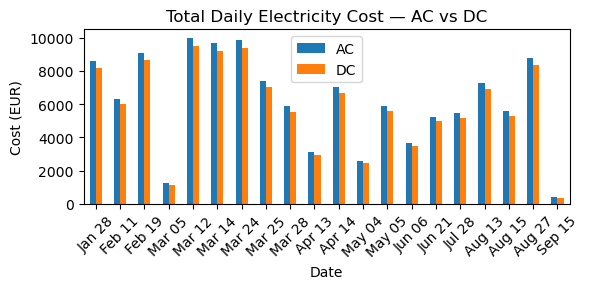

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=FIG_SIZE)
cost_piv.plot(kind='bar', ax=ax)
ax.set_xlabel('Date')
ax.set_ylabel('Cost (EUR)')
ax.set_title('Total Daily Electricity Cost — AC vs DC')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

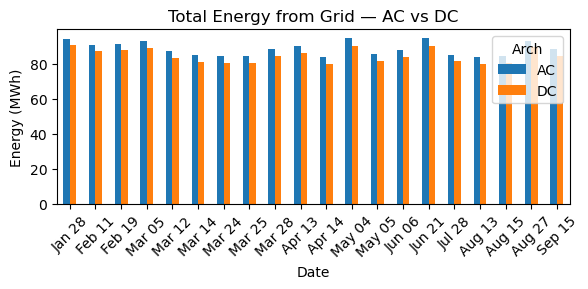

In [36]:
grid_piv = metrics.pivot(index='date', columns='type', values='grid_energy')
grid_piv.index = grid_piv.index.strftime('%b %d')

fig, ax = plt.subplots(figsize=FIG_SIZE)
grid_piv.plot(kind='bar', ax=ax)
ax.set_xlabel('Date')
ax.set_ylabel('Energy (MWh)')
ax.set_title('Total Energy from Grid — AC vs DC')
ax.legend(title='Arch')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

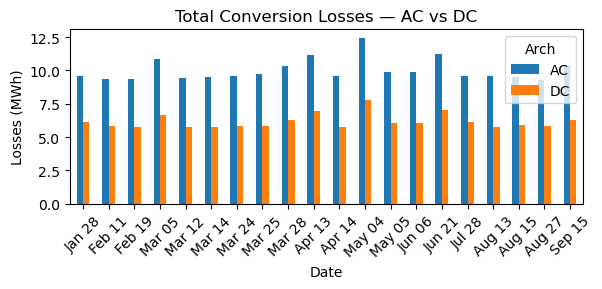

In [37]:
loss_piv = metrics.pivot(index='date', columns='type', values='losses')
loss_piv.index = loss_piv.index.strftime('%b %d')

fig, ax = plt.subplots(figsize=FIG_SIZE)
loss_piv.plot(kind='bar', ax=ax)
ax.set_xlabel('Date')
ax.set_ylabel('Losses (MWh)')
ax.set_title('Total Conversion Losses — AC vs DC')
ax.legend(title='Arch')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
ac_loss = loss_piv['AC']
dc_loss = loss_piv['DC']

reduction_pct = (ac_loss - dc_loss) / ac_loss * 100

load_mwh_per_day = LOAD_MW * N_T * DT
total_load       = load_mwh_per_day * len(ac_loss)

obs = {
    'mean_AC'        : ac_loss.mean(),
    'mean_DC'        : dc_loss.mean(),
    'mean_red_pct'   : reduction_pct.mean(),
    'min_red_pct'    : reduction_pct.min(),
    'max_red_pct'    : reduction_pct.max(),
    'total_AC'       : ac_loss.sum(),
    'total_DC'       : dc_loss.sum(),
    'total_saved'    : (ac_loss - dc_loss).sum(),
    'AC_pct_of_load' : ac_loss.sum() / total_load * 100,
    'DC_pct_of_load' : dc_loss.sum() / total_load * 100,
}

for k, v in obs.items():
    print(f"{k:20s}: {v:.2f}")

mean_AC             : 10.02
mean_DC             : 6.17
mean_red_pct        : 38.43
min_red_pct         : 35.60
max_red_pct         : 40.19
total_AC            : 200.35
total_DC            : 123.38
total_saved         : 76.98
AC_pct_of_load      : 11.82
DC_pct_of_load      : 7.28


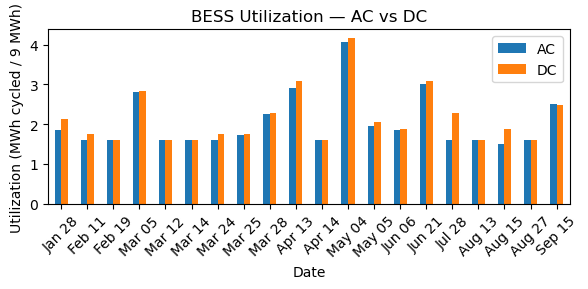

In [39]:
util_piv = metrics.pivot(index='date', columns='type', values='bess_util')
util_piv.index = util_piv.index.strftime('%b %d')

fig, ax = plt.subplots(figsize=FIG_SIZE)
util_piv.plot(kind='bar', ax=ax)
ax.set_xlabel('Date')
ax.set_ylabel('Utilization (MWh cycled / 9 MWh)')
ax.set_title('BESS Utilization — AC vs DC')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

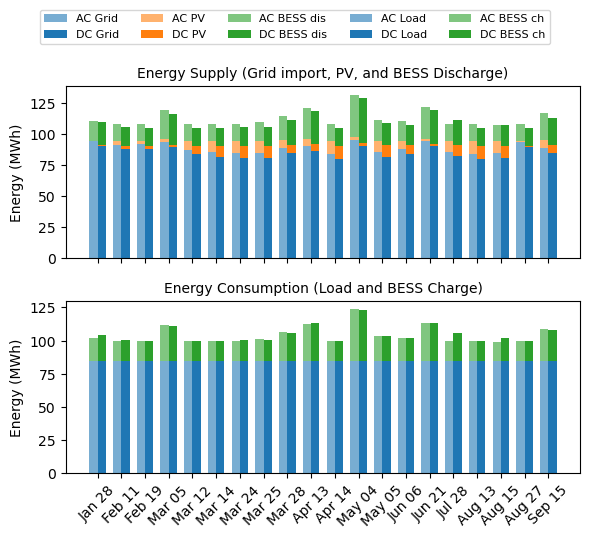

In [40]:
from matplotlib.patches import Patch

load_mwh = LOAD_MW * N_T * DT

ac = metrics[metrics['type'] == 'AC'].set_index('date')
dc = metrics[metrics['type'] == 'DC'].set_index('date')

dates = ac.index.strftime('%b %d')
n     = len(dates)
x     = np.arange(n)
w     = 0.35

fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

for ax, title, cols in [
    (axes[0], 'Energy Supply (Grid import, PV, and BESS Discharge)',  [('grid_energy', 'Grid', 'C0'), ('pv_energy', 'PV', 'C1'), ('dis_mwh', 'BESS dis', 'C2')]),
    (axes[1], 'Energy Consumption (Load and BESS Charge)',          [(None,          'Load', 'C0'), ('charge_mwh', 'BESS ch', 'C2')]),
]:
    for i, (df, label) in enumerate([(ac, 'AC'), (dc, 'DC')]):
        offset = -w / 2 + i * w
        bottom = np.zeros(n)
        for col, name, color in cols:
            vals = np.full(n, load_mwh) if col is None else df[col].values
            ax.bar(x + offset, vals, w, bottom=bottom, color=color, alpha=0.6 + 0.4 * i)
            bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels(dates, rotation=45)
    ax.set_ylabel('Energy (MWh)')
    ax.set_title(title, fontsize=10)

legend_handles = [
    # Row 1 — AC (alpha 0.6)
    Patch(facecolor='C0', alpha=0.6, label='AC Grid'),
    Patch(facecolor='C0', alpha=1.0, label='DC Grid'),

    Patch(facecolor='C1', alpha=0.6, label='AC PV'),
    Patch(facecolor='C1', alpha=1.0, label='DC PV'),
    Patch(facecolor='C2', alpha=0.6, label='AC BESS dis'),
    Patch(facecolor='C2', alpha=1.0, label='DC BESS dis'),
    Patch(facecolor='C0', alpha=0.6, label='AC Load'),
    Patch(facecolor='C0', alpha=1.0, label='DC Load'),
    Patch(facecolor='C2', alpha=0.6, label='AC BESS ch'),
    # Row 2 — DC (alpha 1.0)
    Patch(facecolor='C2', alpha=1.0, label='DC BESS ch'),
]

fig.legend(handles=legend_handles, bbox_to_anchor=(0.5, 0.9), loc='upper center', ncol=5, fontsize=8)
plt.tight_layout(rect=[0, 0, 1, 0.82])
plt.show()

In [41]:
from stage_losses import compute_stage_losses

loss_records = []
for (date, arch), grp in results_all.groupby([results_all.index.normalize(), 'type']):
    res = {col: grp[col].values for col in ['P_grid', 'P_pv_used', 'P_charge', 'P_discharge']}
    out = compute_stage_losses(res, arch=arch)
    row = {'date': date, 'type': arch}
    row.update(out['energy_MWh'])
    row.update(out['totals'])
    loss_records.append(row)

losses_df = pd.DataFrame(loss_records).set_index(['date', 'type'])
losses_df

grid  pv_boost    pv_inv  bess_ch_ac  bess_ch_dc  \
date       type                                                         
2025-01-28 AC    1.577598  0.022199  0.023262    0.516043    0.492825   
           DC    3.181045  0.022199  0.000000    0.000000    0.564108   
2025-02-11 AC    1.526197  0.110936  0.115872    0.439316    0.415525   
           DC    3.167828  0.110936  0.000000    0.000000    0.511329   
2025-02-19 AC    1.527718  0.107241  0.112629    0.412703    0.399018   
           DC    3.184191  0.107241  0.000000    0.000000    0.401840   
2025-03-05 AC    1.488372  0.084216  0.088260    0.827017    0.772930   
           DC    3.035243  0.084216  0.000000    0.000000    0.813317   
2025-03-12 AC    1.461959  0.178033  0.183788    0.415616    0.401761   
           DC    3.046107  0.178033  0.000000    0.000000    0.435193   
2025-03-14 AC    1.465275  0.222015  0.228413    0.428557    0.410617   
           DC    3.103829  0.222015  0.000000    0.000000    0.402114   
2025-03-24 AC    1.466207  0.239501  0.245945    0.412702    0.399012   
           DC    3.129902  0.239501  0.000000    0.000000    0.449267   
2025-03-25 AC    1.531428  0.244832  0.251399    0.462564    0.446446   
           DC    3.115332  0.244832  0.000000    0.000000    0.449267   
2025-03-28 AC    1.526356  0.170583  0.175990    0.621829    0.597736   
           DC    3.149300  0.170583  0.000000    0.000000    0.614355   
2025-04-13 AC    1.542451  0.143955  0.148903    0.812363    0.779935   
           DC    3.260041  0.143955  0.000000    0.000000    0.849747   
2025-04-14 AC    1.463097  0.254290  0.261606    0.411280    0.400857   
           DC    3.043215  0.254290  0.000000    0.000000    0.428948   
2025-05-04 AC    1.576286  0.082959  0.086652    1.153175    1.106031   
           DC    3.307000  0.082959  0.000000    0.000000    1.149747   
2025-05-05 AC    1.440199  0.229199  0.236757    0.514288    0.496639   
           DC    3.019122  0.229199  0.000000    0.000000    0.543084   
2025-06-06 AC    1.544414  0.181104  0.187089    0.506351    0.487014   
           DC    3.223129  0.181104  0.000000    0.000000    0.499494   
2025-06-21 AC    1.570552  0.095745  0.103886    0.853175    0.818523   
           DC    3.313452  0.095745  0.000000    0.000000    0.849747   
2025-07-28 AC    1.483220  0.231594  0.238819    0.428043    0.413413   
           DC    2.974456  0.231594  0.000000    0.000000    0.611107   
2025-08-13 AC    1.493977  0.257145  0.264632    0.425005    0.409981   
           DC    3.111940  0.257145  0.000000    0.000000    0.414236   
2025-08-15 AC    1.517511  0.246791  0.254263    0.405063    0.387637   
           DC    3.106989  0.246791  0.000000    0.000000    0.477996   
2025-08-27 AC    1.540512  0.064467  0.069100    0.434785    0.416031   
           DC    3.214382  0.064467  0.000000    0.000000    0.417203   
2025-09-15 AC    1.456288  0.180506  0.186958    0.668637    0.644599   
           DC    2.986008  0.180506  0.000000    0.000000    0.646919   

                 bess_dis_dc  bess_dis_ac  load_acdc  load_dcdc  \
date       type                                                   
2025-01-28 AC       0.453562     0.447171   3.924377   2.620206   
           DC       0.516804     0.000000   0.000000   2.620206   
2025-02-11 AC       0.402090     0.393923   3.924377   2.620206   
           DC       0.420547     0.000000   0.000000   2.620206   
2025-02-19 AC       0.391434     0.378275   3.924377   2.620206   
           DC       0.387480     0.000000   0.000000   2.620206   
2025-03-05 AC       0.736274     0.724426   3.924377   2.620206   
           DC       0.716345     0.000000   0.000000   2.620206   
2025-03-12 AC       0.391164     0.378035   3.924377   2.620206   
           DC       0.387286     0.000000   0.000000   2.620206   
2025-03-14 AC       0.389210     0.376890   3.924377   2.620206   
           DC       0.388889     0.000000   0.000000   2.620206   
2025-03-24 AC   

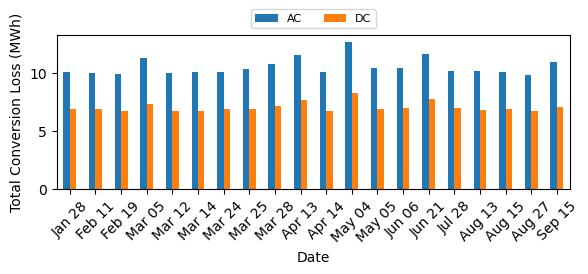

In [42]:
loss_piv = losses_df['total_loss_MWh'].unstack('type')
loss_piv.index = loss_piv.index.strftime('%b %d')

fig, ax = plt.subplots(figsize=FIG_SIZE)
loss_piv.plot(kind='bar', ax=ax)
ax.set_xlabel('Date')
ax.set_ylabel('Total Conversion Loss (MWh)')
ax.legend(bbox_to_anchor=(0.5, 1.2), loc='upper center', ncol=5, fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
loss_piv['loss_diff_%'] = (loss_piv['AC'] - loss_piv['DC'])/loss_piv['AC'] * 100
loss_piv

type,AC,DC,loss_diff_%
date,,,
Jan 28,10.077245,6.904362,31.485615
Feb 11,9.948442,6.830846,31.337527
Feb 19,9.873602,6.700958,32.132582
Mar 05,11.266079,7.269327,35.475978
Mar 12,9.954939,6.666826,33.029969
Mar 14,10.065562,6.737054,33.068277
Mar 24,10.087745,6.858404,32.012510
Mar 25,10.327577,6.851832,33.654992
Mar 28,10.759027,7.128413,33.744812


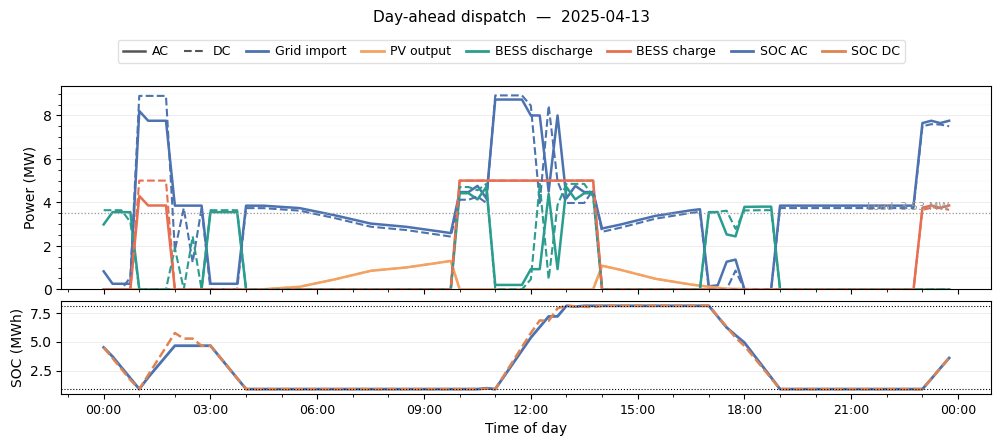

In [44]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines

# ── Pick date ─────────────────────────────────────────────────────────────────
date = sampled_dates[9].strftime('%Y-%m-%d')   # change index or set a date string

# ── Palette ───────────────────────────────────────────────────────────────────
C = {
    'P_grid'      : '#4c72b0',
    'P_pv_used'   : '#f4a261',
    'P_charge'    : '#e76f51',
    'P_discharge' : '#2a9d8f',
    'SOC_AC'      : '#4c72b0',
    'SOC_DC'      : '#dd8452',
}

# ── Pull data ─────────────────────────────────────────────────────────────────
days = {}
for arch in ['AC', 'DC']:
    mask       = (results_all.index.normalize() == pd.Timestamp(date)) & \
                 (results_all['type'] == arch)
    days[arch] = results_all[mask]

t = days['AC'].index

# ── Figure: 2 subplots, shared x, height ratio 2:1 ───────────────────────────
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12,4),
    sharex=True,
    gridspec_kw={'height_ratios': [2.2, 1], 'hspace': 0.08},
)

# ── Top subplot — power flows ─────────────────────────────────────────────────
for arch, ls, lw in [('AC', '-', 1.8), ('DC', '--', 1.5)]:
    d = days[arch]
    ax1.plot(t, d['P_grid'],      color=C['P_grid'],      ls=ls, lw=lw)
    ax1.plot(t, d['P_pv_used'],   color=C['P_pv_used'],   ls=ls, lw=lw)
    ax1.plot(t, d['P_discharge'], color=C['P_discharge'], ls=ls, lw=lw)
    ax1.plot(t, d['P_charge'],    color=C['P_charge'],    ls=ls, lw=lw)

ax1.axhline(LOAD_MW, color='#999', lw=0.9, ls=':')
ax1.text(t[-1], LOAD_MW + 0.06, f'Load  {LOAD_MW} MW',
         ha='right', va='bottom', fontsize=8, color='#999')

ax1.set_ylabel('Power (MW)', fontsize=10)
ax1.set_ylim(bottom=0)
ax1.yaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax1.grid(axis='y', lw=0.4, alpha=0.4)
ax1.grid(axis='y', which='minor', lw=0.2, alpha=0.2)
ax1.spines[['top', 'right']].set_visible(True)

# ── Bottom subplot — SOC ──────────────────────────────────────────────────────
for arch, color, ls, lw in [('AC', C['SOC_AC'], '-', 2), ('DC', C['SOC_DC'], '--', 1.8)]:
    ax2.plot(t, days[arch]['SOC'], color=color, ls=ls, lw=lw)

ax2.axhline(SOC_MIN, color='black', lw=0.8, ls=':')
ax2.axhline(SOC_MAX, color='black', lw=0.8, ls=':')
# ax2.text(t[-1], SOC_MIN - 0.12, f'min  {SOC_MIN} MWh',
#          ha='right', va='top',    fontsize=7.5, color='#aaa')
# ax2.text(t[-1], SOC_MAX + 0.08, f'max  {SOC_MAX} MWh',
#          ha='right', va='bottom', fontsize=7.5, color='#aaa')

ax2.set_ylabel('SOC (MWh)', fontsize=10)
ax2.set_ylim(SOC_MIN - 0.4, SOC_MAX + 0.4)
ax2.grid(axis='y', lw=0.4, alpha=0.4)
ax2.spines[['top', 'right']].set_visible(True)

ax2.xaxis.set_major_locator(mdates.HourLocator(byhour=range(0, 25, 3)))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.xaxis.set_minor_locator(mdates.HourLocator(byhour=range(0, 25, 1)))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=0, ha='center', fontsize=9)
ax2.set_xlabel('Time of day', fontsize=10)

# ── Single legend at top of figure, outside the subplots ─────────────────────
legend_handles = [
    mlines.Line2D([0], [0], color='#555', ls='-',   lw=1.8, label='AC'),
    mlines.Line2D([0], [0], color='#555', ls='--',  lw=1.5, label='DC'),
    mlines.Line2D([0], [0], color=C['P_grid'],      lw=2,   label='Grid import'),
    mlines.Line2D([0], [0], color=C['P_pv_used'],   lw=2,   label='PV output'),
    mlines.Line2D([0], [0], color=C['P_discharge'], lw=2,   label='BESS discharge'),
    mlines.Line2D([0], [0], color=C['P_charge'],    lw=2,   label='BESS charge'),
    mlines.Line2D([0], [0], color=C['SOC_AC'],      lw=2,   label='SOC AC'),
    mlines.Line2D([0], [0], color=C['SOC_DC'],      lw=2,   label='SOC DC'),
]

fig.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.01),
    ncol=len(legend_handles),
    fontsize=9,
    framealpha=0.9,
    edgecolor='#ddd',
    handlelength=1.8,
    handletextpad=0.5,
    columnspacing=1.2,
)

fig.suptitle(f'Day-ahead dispatch  —  {date}', fontsize=11, fontweight='500', y=1.07)

plt.show()

════════════════════════════════════════════════════════════
  [A]  COST SAVINGS  (literature: 2 % – 19 %)
════════════════════════════════════════════════════════════
type        AC cost (€)  DC cost (€)  Saving (%)
date                                            
2025-01-28      8581.50      8191.09        4.55
2025-02-11      6299.09      6011.53        4.57
2025-02-19      9073.20      8669.06        4.45
2025-03-05      1226.09      1141.36        6.91
2025-03-12     10003.94      9527.05        4.77
2025-03-14      9684.88      9215.56        4.85
2025-03-24      9866.10      9364.51        5.08
2025-03-25      7392.51      7002.58        5.27
2025-03-28      5858.70      5543.30        5.38
2025-04-13      3110.68      2949.97        5.17
2025-04-14      7054.33      6675.89        5.36
2025-05-04      2578.28      2442.46        5.27
2025-05-05      5915.30      5596.24        5.39
2025-06-06      3681.21      3482.10        5.41
2025-06-21      5242.11      4990.38        4.80

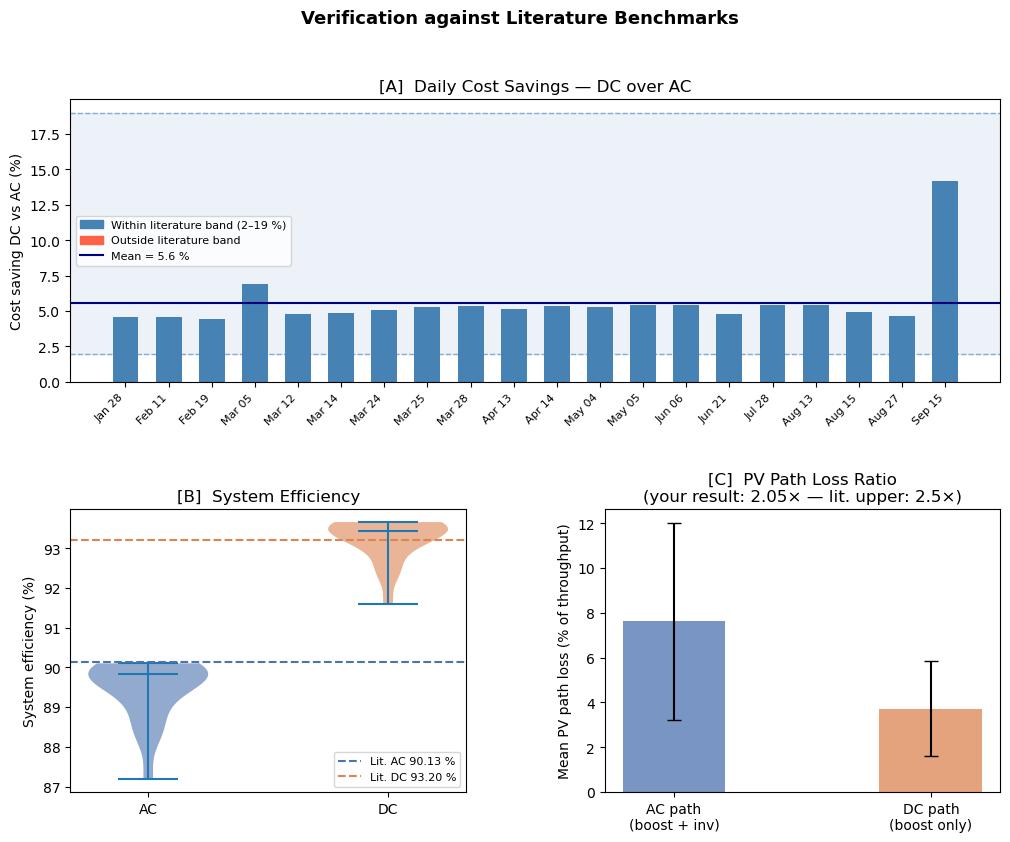


Figure saved → verification_vs_literature.png


In [45]:
# ═══════════════════════════════════════════════════════════════════════════
# VERIFICATION — comparing results against three literature benchmarks
#
# The text (excerpt_from_previous_claude_message.txt) makes three claims:
#
#   [A] DC cost savings range from 2% to as much as 19% across operating days
#   [B] AC system efficiency ~90.13% vs DC ~93.20% (≈ 3 pp gap)
#   [C] AC/DC boost converters lose up to 2.5× more than DC/DC equivalents
#       at component level (100–500 W range)
#
# This cell computes each against your actual results_all / metrics data.
# ═══════════════════════════════════════════════════════════════════════════

from stage_losses import compute_stage_losses

load_mwh_per_day = LOAD_MW * N_T * DT   # constant daily load energy

# ── [A]  Cost savings per day ────────────────────────────────────────────────
cost_piv_raw = metrics.pivot(index='date', columns='type', values='cost_eur')
cost_piv_raw['savings_pct'] = (
    (cost_piv_raw['AC'] - cost_piv_raw['DC']) / cost_piv_raw['AC'] * 100
)

print("═" * 60)
print("  [A]  COST SAVINGS  (literature: 2 % – 19 %)")
print("═" * 60)
print(cost_piv_raw[['AC', 'DC', 'savings_pct']].rename(
    columns={'AC': 'AC cost (€)', 'DC': 'DC cost (€)', 'savings_pct': 'Saving (%)'}
).to_string(float_format=lambda x: f"{x:.2f}"))
print(f"\n  Min saving : {cost_piv_raw['savings_pct'].min():.2f} %")
print(f"  Max saving : {cost_piv_raw['savings_pct'].max():.2f} %")
print(f"  Mean saving: {cost_piv_raw['savings_pct'].mean():.2f} %")
in_range = cost_piv_raw['savings_pct'].between(2, 19)
print(f"  Days within 2–19 % band: {in_range.sum()} / {len(in_range)}")

# ── [B]  System efficiency per architecture ──────────────────────────────────
# System efficiency = load energy delivered / (grid energy + PV energy)
metrics['energy_in']       = metrics['grid_energy'] + metrics['pv_energy']
metrics['sys_efficiency']  = load_mwh_per_day / metrics['energy_in'] * 100

eff_by_arch = metrics.groupby('type')['sys_efficiency'].agg(['mean', 'min', 'max'])

print("\n" + "═" * 60)
print("  [B]  SYSTEM EFFICIENCY  (literature: AC ≈ 90.1 %  DC ≈ 93.2 %)")
print("═" * 60)
print(eff_by_arch.rename(
    columns={'mean': 'Mean (%)', 'min': 'Min (%)', 'max': 'Max (%)'}
).to_string(float_format=lambda x: f"{x:.2f}"))
eff_gap = (
    eff_by_arch.loc['DC', 'mean'] - eff_by_arch.loc['AC', 'mean']
)
print(f"\n  Efficiency gap (DC − AC): {eff_gap:.2f} pp  (literature: ≈ 3 pp)")

# ── [C]  Component-level loss ratio: AC/DC vs DC/DC ─────────────────────────
# Run compute_stage_losses on every day for both architectures and extract:
#   AC path:   pv_boost + pv_inv  (two stages)   vs  DC path: pv_boost only
# We compare absolute losses per MWh of PV throughput on the PV path.

ac_pv_loss_per_mwh = []
dc_pv_loss_per_mwh = []

for dt in sampled_dates:
    date = dt.strftime('%Y-%m-%d')
    for arch, bucket in [('AC', ac_pv_loss_per_mwh), ('DC', dc_pv_loss_per_mwh)]:
        mask = (results_all.index.normalize() == dt) & (results_all['type'] == arch)
        day  = results_all[mask]
        if day.empty:
            continue
        res_dict = {
            'P_grid'      : day['P_grid'].values,
            'P_pv_used'   : day['P_pv_used'].values,
            'P_charge'    : day['P_charge'].values,
            'P_discharge' : day['P_discharge'].values,
        }
        out      = compute_stage_losses(res_dict, arch=arch)
        pv_in    = out['totals']['pv_energy_MWh']
        if arch == 'AC':
            pv_loss = out['energy_MWh']['pv_boost'] + out['energy_MWh']['pv_inv']
        else:
            pv_loss = out['energy_MWh']['pv_boost']

        if pv_in > 0.01:
            bucket.append(pv_loss / pv_in * 100)   # loss as % of PV throughput

ac_pv_loss_pct = np.mean(ac_pv_loss_per_mwh)
dc_pv_loss_pct = np.mean(dc_pv_loss_per_mwh)
ratio          = ac_pv_loss_pct / dc_pv_loss_pct if dc_pv_loss_pct > 0 else float('nan')

print("\n" + "═" * 60)
print("  [C]  PV PATH LOSS RATIO: AC/DC vs DC/DC")
print("       (literature: AC/DC converters lose up to 2.5× more)")
print("═" * 60)
print(f"  Mean AC PV-path loss (boost + inv)  : {ac_pv_loss_pct:.3f} %  of PV throughput")
print(f"  Mean DC PV-path loss (boost only)   : {dc_pv_loss_pct:.3f} %  of PV throughput")
print(f"  AC/DC loss ratio                    : {ratio:.2f} ×  (literature upper bound: 2.5×)")

# ── Summary plot ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 9))
fig.suptitle("Verification against Literature Benchmarks", fontsize=13, fontweight='bold')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

dates_str = cost_piv_raw.index.strftime('%b %d')
x         = np.arange(len(dates_str))

# ── Panel A: cost savings per day with 2–19 % band shaded ───────────────────
ax_a = fig.add_subplot(gs[0, :])
bars = ax_a.bar(x, cost_piv_raw['savings_pct'], color=np.where(in_range, 'steelblue', 'tomato'), width=0.6)
ax_a.axhspan(2, 19, color='steelblue', alpha=0.10, label='Literature band (2–19 %)')
ax_a.axhline(2,  color='steelblue', lw=1, ls='--', alpha=0.6)
ax_a.axhline(19, color='steelblue', lw=1, ls='--', alpha=0.6)
ax_a.axhline(cost_piv_raw['savings_pct'].mean(), color='navy', lw=1.5, ls='-', label=f'Mean = {cost_piv_raw["savings_pct"].mean():.1f} %')
ax_a.set_xticks(x); ax_a.set_xticklabels(dates_str, rotation=45, ha='right', fontsize=8)
ax_a.set_ylabel('Cost saving DC vs AC (%)')
ax_a.set_title('[A]  Daily Cost Savings — DC over AC')
ax_a.legend(fontsize=8)
from matplotlib.patches import Patch
ax_a.legend(handles=[
    Patch(color='steelblue', label='Within literature band (2–19 %)'),
    Patch(color='tomato',    label='Outside literature band'),
    plt.Line2D([0], [0], color='navy', lw=1.5, label=f'Mean = {cost_piv_raw["savings_pct"].mean():.1f} %'),
], fontsize=8)

# ── Panel B: system efficiency violin / bar ─────────────────────────────────
ax_b = fig.add_subplot(gs[1, 0])
eff_ac = metrics[metrics['type'] == 'AC']['sys_efficiency'].values
eff_dc = metrics[metrics['type'] == 'DC']['sys_efficiency'].values
parts  = ax_b.violinplot([eff_ac, eff_dc], positions=[0, 1], showmedians=True, showextrema=True)
for pc, color in zip(parts['bodies'], ['#4c72b0', '#dd8452']):
    pc.set_facecolor(color); pc.set_alpha(0.6)
ax_b.axhline(90.13, color='#4c72b0', lw=1.5, ls='--', label='Lit. AC 90.13 %')
ax_b.axhline(93.20, color='#dd8452', lw=1.5, ls='--', label='Lit. DC 93.20 %')
ax_b.set_xticks([0, 1]); ax_b.set_xticklabels(['AC', 'DC'])
ax_b.set_ylabel('System efficiency (%)')
ax_b.set_title('[B]  System Efficiency')
ax_b.legend(fontsize=8)

# ── Panel C: PV path loss comparison ────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 1])
ac_vals = np.array(ac_pv_loss_per_mwh)
dc_vals = np.array(dc_pv_loss_per_mwh)
ax_c.bar([0, 1], [ac_pv_loss_pct, dc_pv_loss_pct], color=['#4c72b0', '#dd8452'], alpha=0.75, width=0.4)
ax_c.errorbar([0, 1], [ac_pv_loss_pct, dc_pv_loss_pct],
              yerr=[ac_vals.std(), dc_vals.std()], fmt='none', color='black', capsize=5)
ax_c.set_xticks([0, 1])
ax_c.set_xticklabels(['AC path\n(boost + inv)', 'DC path\n(boost only)'])
ax_c.set_ylabel('Mean PV path loss (% of throughput)')
ax_c.set_title(f'[C]  PV Path Loss Ratio\n(your result: {ratio:.2f}× — lit. upper: 2.5×)')

# plt.savefig('verification_vs_literature.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure saved → verification_vs_literature.png")

Running constant-eta model …
Done — 3840 rows (40 day-arch pairs)

═════════════════════════════════════════════════════════════════
  OPTIMALITY GAP  (constant-η cost − variable-η cost) / variable-η cost
  Literature benchmark: ~11.4 % (Qi, Baker & Xu, 2025)
═════════════════════════════════════════════════════════════════
  AC:  mean = -1.17 %   min = -2.46 %   max = -0.97 %
  DC:  mean = -0.62 %   min = -1.17 %   max = -0.44 %

═════════════════════════════════════════════════════════════════
  SYSTEM EFFICIENCY DIFFERENCE  (variable-η − constant-η) [pp]
  Positive = variable-η model reports higher system efficiency
═════════════════════════════════════════════════════════════════
  AC:  mean = -0.910 pp   min = -1.433 pp   max = -0.677 pp
  DC:  mean = -0.578 pp   min = -1.176 pp   max = -0.369 pp

═════════════════════════════════════════════════════════════════
  ARCHITECTURE GAP:  AC cost − DC cost  per model
═════════════════════════════════════════════════════════════════
  Va

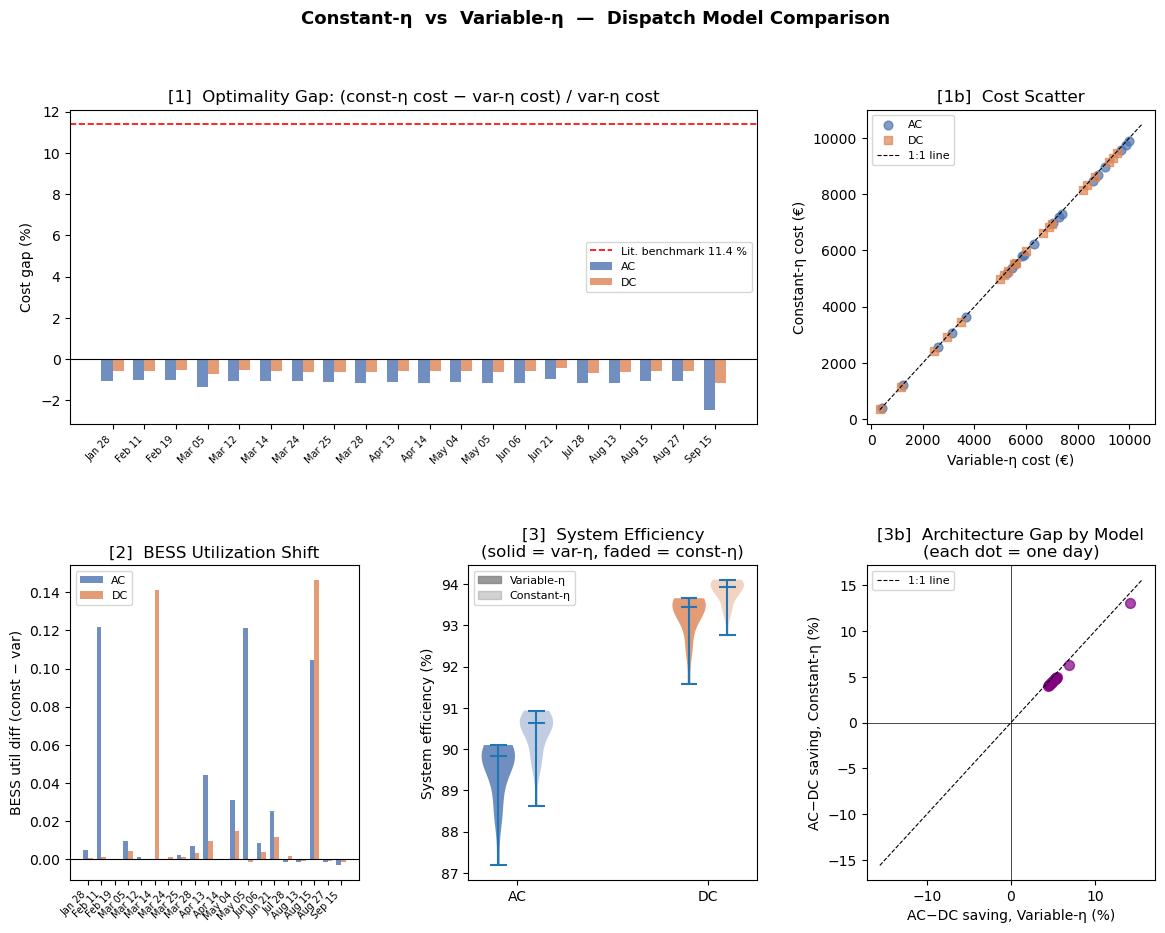

Figure saved → const_vs_var_eta_comparison.png

── Constant-η values used ──────────────────────────────────────────────
  PV DC/DC boost      : 0.979
  PV DC/AC inverter   : 0.978
  BESS AC/DC          : 0.974
  BESS DC/DC          : 0.974
  Load AC/DC rectifier: 0.961
  MV/LV transformer   : 0.988


In [46]:

from deterministic_MG_scheduler_const_eta import (
    build_and_solve as build_and_solve_const,
    PV_DCAC_ETA_CONST, PV_DCDC_ETA_CONST,
    BESS_DCAC_ETA_CONST, BESS_DCDC_ETA_CONST,
    LOAD_ACDC_ETA_CONST, TRAFO_ETA_CONST,
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── 1.  Run constant-eta model for all sampled dates × 2 architectures ───────
print("Running constant-eta model …")
dfs_const = []

for arch in ['AC', 'DC']:
    for dt in sampled_dates:
        date      = dt.strftime('%Y-%m-%d')
        price_day = price_15min[date].values
        pv_day    = pv_15min[date].values

        res = build_and_solve_const(price_day, pv_day, arch=arch, soc_init=4.5)
        if res['status'] != 'optimal':
            print(f"  WARNING: {arch} {date} → {res['status']}")
            continue

        res['SOC'] = res['SOC'][:-1]   # trim terminal SOC to match N_T length
        idx = price_15min[date].index
        df  = pd.DataFrame(
            {k: v for k, v in res.items()
             if isinstance(v, np.ndarray) and len(v) == N_T},
            index=idx
        )
        df['cost_eur'] = res['cost_eur']
        df['type']     = arch
        dfs_const.append(df)

results_const = pd.concat(dfs_const)
print(f"Done — {results_const.shape[0]} rows ({results_const.shape[0] // N_T} day-arch pairs)")

# ── 2.  Build metrics table for constant-eta results ─────────────────────────
daily_const             = results_const.copy()
daily_const['date']     = daily_const.index.normalize()

metrics_const = daily_const.groupby(['date', 'type']).agg(
    cost_eur    = ('cost_eur',    'first'),
    grid_energy = ('P_grid',      lambda x: x.sum() * DT),
    pv_energy   = ('P_pv_used',   lambda x: x.sum() * DT),
    charge_mwh  = ('P_charge',    lambda x: x.sum() * DT),
    dis_mwh     = ('P_discharge', lambda x: x.sum() * DT),
).reset_index()

metrics_const['bess_util'] = (
    (metrics_const['charge_mwh'] + metrics_const['dis_mwh']) / 2 / BESS_CAP_MWH
)
metrics_const['sys_efficiency'] = (
    LOAD_MW * N_T * DT / (metrics_const['grid_energy'] + metrics_const['pv_energy']) * 100
)

# ── 3.  Build combined comparison table ──────────────────────────────────────
# For each (date, arch) join variable-eta and constant-eta metrics side by side

daily_var              = results_all.copy()
daily_var['date']      = daily_var.index.normalize()

metrics_var = daily_var.groupby(['date', 'type']).agg(
    cost_eur    = ('cost_eur',    'first'),
    grid_energy = ('P_grid',      lambda x: x.sum() * DT),
    pv_energy   = ('P_pv_used',   lambda x: x.sum() * DT),
    charge_mwh  = ('P_charge',    lambda x: x.sum() * DT),
    dis_mwh     = ('P_discharge', lambda x: x.sum() * DT),
).reset_index()

metrics_var['bess_util']      = (metrics_var['charge_mwh'] + metrics_var['dis_mwh']) / 2 / BESS_CAP_MWH
metrics_var['sys_efficiency'] = LOAD_MW * N_T * DT / (metrics_var['grid_energy'] + metrics_var['pv_energy']) * 100

# Join on (date, type)
comp = metrics_var.merge(
    metrics_const[['date', 'type', 'cost_eur', 'grid_energy', 'bess_util', 'sys_efficiency']],
    on=['date', 'type'],
    suffixes=('_var', '_const')
)

# Optimality gap: how much MORE the constant-eta model pays vs variable-eta
# (positive = constant-eta is sub-optimal / more expensive)
comp['cost_gap_pct']   = (comp['cost_eur_const'] - comp['cost_eur_var']) / comp['cost_eur_var'].abs() * 100
comp['grid_gap_mwh']   = comp['grid_energy_const'] - comp['grid_energy_var']
comp['bess_util_diff'] = comp['bess_util_const']   - comp['bess_util_var']
comp['eff_diff_pp']    = comp['sys_efficiency_var'] - comp['sys_efficiency_const']

# ── 4.  Print summary statistics ─────────────────────────────────────────────
print("\n" + "═" * 65)
print("  OPTIMALITY GAP  (constant-η cost − variable-η cost) / variable-η cost")
print("  Literature benchmark: ~11.4 % (Qi, Baker & Xu, 2025)")
print("═" * 65)
for arch in ['AC', 'DC']:
    sub = comp[comp['type'] == arch]['cost_gap_pct']
    print(f"  {arch}:  mean = {sub.mean():+.2f} %   "
          f"min = {sub.min():+.2f} %   max = {sub.max():+.2f} %")

print("\n" + "═" * 65)
print("  SYSTEM EFFICIENCY DIFFERENCE  (variable-η − constant-η) [pp]")
print("  Positive = variable-η model reports higher system efficiency")
print("═" * 65)
for arch in ['AC', 'DC']:
    sub = comp[comp['type'] == arch]['eff_diff_pp']
    print(f"  {arch}:  mean = {sub.mean():+.3f} pp   "
          f"min = {sub.min():+.3f} pp   max = {sub.max():+.3f} pp")

print("\n" + "═" * 65)
print("  ARCHITECTURE GAP:  AC cost − DC cost  per model")
print("═" * 65)
for label, m_ in [('Variable-η', metrics_var), ('Constant-η', metrics_const)]:
    cpiv = m_.pivot(index='date', columns='type', values='cost_eur')
    gap  = (cpiv['AC'] - cpiv['DC']) / cpiv['AC'] * 100
    print(f"  {label}:  mean AC-DC saving = {gap.mean():.2f} %   "
          f"range [{gap.min():.2f} %, {gap.max():.2f} %]")

# ── 5.  Plots ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
fig.suptitle("Constant-η  vs  Variable-η  —  Dispatch Model Comparison", fontsize=13, fontweight='bold')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

dates_str = comp[comp['type'] == 'AC']['date'].dt.strftime('%b %d').values
x         = np.arange(len(dates_str))
w         = 0.35

# ── Panel 1: optimality gap (cost) per day, both architectures ───────────────
ax1 = fig.add_subplot(gs[0, :2])
gap_ac = comp[comp['type'] == 'AC'].set_index('date')['cost_gap_pct'].values
gap_dc = comp[comp['type'] == 'DC'].set_index('date')['cost_gap_pct'].values
ax1.bar(x - w/2, gap_ac, w, label='AC',  color='#4c72b0', alpha=0.8)
ax1.bar(x + w/2, gap_dc, w, label='DC',  color='#dd8452', alpha=0.8)
ax1.axhline(0,    color='black', lw=0.8, ls='-')
ax1.axhline(11.4, color='red', lw=1.2, ls='--', label='Lit. benchmark 11.4 %')
ax1.set_xticks(x); ax1.set_xticklabels(dates_str, rotation=45, ha='right', fontsize=7)
ax1.set_ylabel('Cost gap (%)')
ax1.set_title('[1]  Optimality Gap: (const-η cost − var-η cost) / var-η cost')
ax1.legend(fontsize=8)

# ── Panel 2: scatter — var-η cost vs const-η cost ────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
for arch, color, marker in [('AC', '#4c72b0', 'o'), ('DC', '#dd8452', 's')]:
    sub = comp[comp['type'] == arch]
    ax2.scatter(sub['cost_eur_var'], sub['cost_eur_const'],
                color=color, marker=marker, alpha=0.7, label=arch, s=40)
lim_lo = comp[['cost_eur_var', 'cost_eur_const']].min().min() * 0.95
lim_hi = comp[['cost_eur_var', 'cost_eur_const']].max().max() * 1.05
ax2.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=0.8, label='1:1 line')
ax2.set_xlabel('Variable-η cost (€)')
ax2.set_ylabel('Constant-η cost (€)')
ax2.set_title('[1b]  Cost Scatter')
ax2.legend(fontsize=8)

# ── Panel 3: BESS utilization difference ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
util_diff_ac = comp[comp['type'] == 'AC'].set_index('date')['bess_util_diff'].values
util_diff_dc = comp[comp['type'] == 'DC'].set_index('date')['bess_util_diff'].values
ax3.bar(x - w/2, util_diff_ac, w, label='AC', color='#4c72b0', alpha=0.8)
ax3.bar(x + w/2, util_diff_dc, w, label='DC', color='#dd8452', alpha=0.8)
ax3.axhline(0, color='black', lw=0.8)
ax3.set_xticks(x); ax3.set_xticklabels(dates_str, rotation=45, ha='right', fontsize=7)
ax3.set_ylabel('BESS util diff (const − var)')
ax3.set_title('[2]  BESS Utilization Shift')
ax3.legend(fontsize=8)

# ── Panel 4: system efficiency — violin comparison ───────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
positions = [0.8, 1.2, 2.8, 3.2]
data      = [
    metrics_var  [metrics_var  ['type'] == 'AC']['sys_efficiency'].values,
    metrics_const[metrics_const['type'] == 'AC']['sys_efficiency'].values,
    metrics_var  [metrics_var  ['type'] == 'DC']['sys_efficiency'].values,
    metrics_const[metrics_const['type'] == 'DC']['sys_efficiency'].values,
]
colors = ['#4c72b0', '#4c72b0', '#dd8452', '#dd8452']
alphas = [0.8, 0.35, 0.8, 0.35]
vp     = ax4.violinplot(data, positions=positions, showmedians=True, widths=0.35)
for pc, color, alpha in zip(vp['bodies'], colors, alphas):
    pc.set_facecolor(color); pc.set_alpha(alpha)
ax4.set_xticks([1.0, 3.0])
ax4.set_xticklabels(['AC', 'DC'])
ax4.set_ylabel('System efficiency (%)')
ax4.set_title('[3]  System Efficiency\n(solid = var-η, faded = const-η)')
from matplotlib.patches import Patch
ax4.legend(handles=[
    Patch(color='grey', alpha=0.8, label='Variable-η'),
    Patch(color='grey', alpha=0.35, label='Constant-η'),
], fontsize=8)

# ── Panel 5: AC−DC cost gap by model type ────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
cpiv_var   = metrics_var.pivot(  index='date', columns='type', values='cost_eur')
cpiv_const = metrics_const.pivot(index='date', columns='type', values='cost_eur')
gap_var    = (cpiv_var  ['AC'] - cpiv_var  ['DC']) / cpiv_var  ['AC'] * 100
gap_const  = (cpiv_const['AC'] - cpiv_const['DC']) / cpiv_const['AC'] * 100

ax5.scatter(gap_var.values, gap_const.values, color='purple', alpha=0.7, s=50)
lim = max(gap_var.abs().max(), gap_const.abs().max()) * 1.1
ax5.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8, label='1:1 line')
ax5.axhline(0, color='black', lw=0.5)
ax5.axvline(0, color='black', lw=0.5)
ax5.set_xlabel('AC−DC saving, Variable-η (%)')
ax5.set_ylabel('AC−DC saving, Constant-η (%)')
ax5.set_title('[3b]  Architecture Gap by Model\n(each dot = one day)')
ax5.legend(fontsize=8)

# plt.savefig('const_vs_var_eta_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → const_vs_var_eta_comparison.png")

# ── 6.  Constant-eta values printed for reference ────────────────────────────
print("\n── Constant-η values used ──────────────────────────────────────────────")
print(f"  PV DC/DC boost      : {PV_DCDC_ETA_CONST:.3f}")
print(f"  PV DC/AC inverter   : {PV_DCAC_ETA_CONST:.3f}")
print(f"  BESS AC/DC          : {BESS_DCAC_ETA_CONST:.3f}")
print(f"  BESS DC/DC          : {BESS_DCDC_ETA_CONST:.3f}")
print(f"  Load AC/DC rectifier: {LOAD_ACDC_ETA_CONST:.3f}")
print(f"  MV/LV transformer   : {TRAFO_ETA_CONST:.3f}")
